# Exp0.1.5 — Gradient-Calibrated All-Fixes Regularization

Analysis-only notebook for the finalized 5% / 10% / 20% hidden-gradient strength sweep. Training and Slurm submission are intentionally outside this notebook.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("artifacts/experiment_0_1_5_gradient_calibrated_all_fixes/gradient_calibrated_all_fixes_v1")
if not ROOT.exists():
    ROOT = Path("notebooks") / ROOT

runs = pd.read_csv(ROOT / "runs.csv")
summary = pd.read_csv(ROOT / "summary.csv")
history = pd.read_csv(ROOT / "history_long.csv")
calibrations = pd.read_csv(ROOT / "calibrations.csv")
calibration_summary = pd.read_csv(ROOT / "calibration_summary.csv")
gradient_summary = pd.read_csv(ROOT / "gradient_trajectory_summary.csv")
stopping_summary = pd.read_csv(ROOT / "stopping_summary.csv")
paired = pd.read_csv(ROOT / "paired_vs_frozen_exp01.csv")
paired_summary = pd.read_csv(ROOT / "paired_vs_frozen_exp01_summary.csv")
frozen = pd.read_csv(ROOT / "frozen_exp01_binary_context.csv")
frozen_summary = pd.read_csv(ROOT / "frozen_exp01_summary.csv")
comparison = pd.read_csv(ROOT / "comparison_summary.csv")
manifest = json.loads((ROOT / "manifest.json").read_text(encoding="utf-8"))

print("runs:", runs.shape, "history:", history.shape, "calibrations:", calibrations.shape)
assert len(runs) == 90
assert set(runs["target_grad_ratio"]) == {0.05, 0.10, 0.20}
assert len(frozen) == 30


runs: (90, 25) history: (6950, 32) calibrations: (90, 10)


## Experiment contract


In [3]:
print(json.dumps(manifest, indent=2))


{
  "all_fixes_formulation": {
    "a1": "Exp0.1.4 hidden valid-neuron-step firing mean, then mean layers",
    "base_regularizer": "0.01 * P2_all_fixes + 0.1 * A1",
    "p2_reduction": "mean batch/neuron within layer, then mean layers",
    "potential_source": "hidden pre-reset membrane",
    "source": "Exp0.1.4 all_fixes",
    "tau_gain_normalization": "multiply membrane by (1-alpha_i) only on the P2 path",
    "temporal_normalization": "divide cumulative EW endpoint by valid EW mass",
    "warmup": "linear scale=min(1, epoch/10)"
  },
  "experiment_id": "experiment_0_1_5_gradient_calibrated_all_fixes",
  "frozen_baseline": {
    "experiment_id": "experiment_0_1_general_comparison",
    "note": "Exp0.1 100-epoch binary direct-SNN runs are reused; they are not equal-compute controls.",
    "protocol_version": "general_comparison_v1",
    "runs": 30
  },
  "gradient_calibration": {
    "aggregation": "median per-batch ||grad R0|| / ||grad task||",
    "kappa": "target_ratio / calibrati

## 5-seed test performance by target strength


In [4]:
main_cols = [
    "target_grad_ratio", "architecture", "objective",
    "test_ba_mean", "test_ba_std", "test_ba_count",
    "val_ba_mean", "epochs_trained_mean", "best_epoch_mean", "kappa_mean",
]
main = summary[main_cols].sort_values("test_ba_mean", ascending=False)
display(main.reset_index(drop=True))


,target_grad_ratio,architecture,objective,test_ba_mean,test_ba_std,test_ba_count,val_ba_mean,epochs_trained_mean,best_epoch_mean,kappa_mean
0,0.05,short_mid,whole_count_ce,0.438448,0.056692,5,0.426774,100.0,94.6,1.009071
1,0.10,short_mid,whole_count_ce,0.388792,0.065616,5,0.365874,100.0,91.4,2.018142
2,0.10,mid_long,whole_count_ce,0.377700,0.020539,5,0.312167,100.0,89.0,3.103013
3,0.05,mid_long,whole_count_ce,0.373622,0.052747,5,0.349123,100.0,87.6,1.551506
4,0.20,mid_long,whole_count_ce,0.318086,0.066360,5,0.275818,96.2,84.6,6.206026
5,0.20,short_mid,whole_count_ce,0.309183,0.152473,5,0.279885,90.0,76.2,4.036281
6,0.05,short_mid,timestep_ce,0.212107,0.036720,5,0.179167,100.0,96.2,1.707752
7,0.05,mid_long,timestep_ce,0.205178,0.088645,5,0.196006,88.6,72.6,3.013170
8,0.10,short_mid,timestep_ce,0.130610,0.063849,5,0.122778,80.0,59.4,3.415503
9,0.10,mid_long,timestep_ce,0.115766,0.058953,5,0.122619,62.0,25.0,6.026340


## Paired test-BA change versus frozen Exp0.1 no-reg


In [5]:
delta_cols = [
    "target_grad_ratio", "architecture", "objective",
    "delta_test_ba_vs_frozen_exp01_mean",
    "delta_test_ba_vs_frozen_exp01_std",
    "delta_test_ba_vs_frozen_exp01_count",
]
delta = paired_summary[delta_cols].sort_values(
    "delta_test_ba_vs_frozen_exp01_mean", ascending=False
)
display(delta.reset_index(drop=True))

pivot = delta.pivot_table(
    index=["architecture", "objective"],
    columns="target_grad_ratio",
    values="delta_test_ba_vs_frozen_exp01_mean",
)
display(pivot)


,target_grad_ratio,architecture,objective,delta_test_ba_vs_frozen_exp01_mean,delta_test_ba_vs_frozen_exp01_std,delta_test_ba_vs_frozen_exp01_count
0,0.05,short_mid,whole_count_ce,-0.018763,0.037834,5
1,0.10,mid_long,whole_count_ce,-0.023090,0.038128,5
2,0.05,mid_long,whole_count_ce,-0.027168,0.047254,5
3,0.05,short_mid_long,timestep_ce,-0.041953,0.020311,5
4,0.10,short_mid_long,timestep_ce,-0.045200,0.017921,5
5,0.20,short_mid_long,timestep_ce,-0.049421,0.018569,5
6,0.10,short_mid,whole_count_ce,-0.068418,0.048267,5
7,0.05,short_mid,timestep_ce,-0.069357,0.053871,5
8,0.20,mid_long,whole_count_ce,-0.082704,0.065283,5
9,0.05,mid_long,timestep_ce,-0.098856,0.057350,5


target_grad_ratio                  0.05      0.10      0.20
architecture   objective                                   
mid_long       timestep_ce    -0.098856 -0.188268 -0.208104
               whole_count_ce -0.027168 -0.023090 -0.082704
short_mid      timestep_ce    -0.069357 -0.150854 -0.189321
               whole_count_ce -0.018763 -0.068418 -0.148028
short_mid_long timestep_ce    -0.041953 -0.045200 -0.049421
               whole_count_ce -0.128979 -0.130411 -0.130411

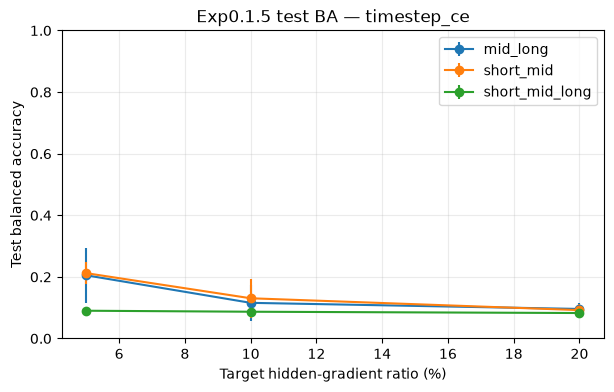

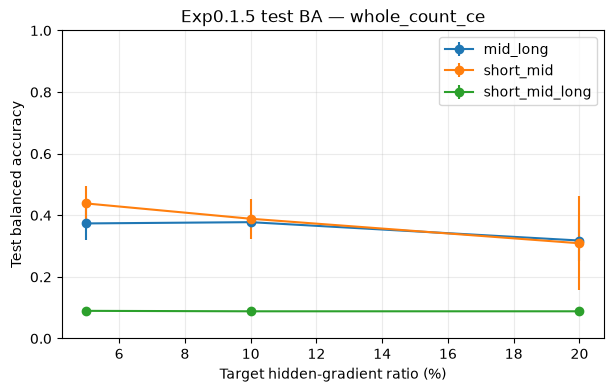

In [6]:
for objective in sorted(runs["objective"].unique()):
    fig, ax = plt.subplots(figsize=(7, 4))
    part = summary[summary["objective"] == objective]
    for architecture in sorted(part["architecture"].unique()):
        sub = part[part["architecture"] == architecture].sort_values("target_grad_ratio")
        ax.errorbar(
            100 * sub["target_grad_ratio"],
            sub["test_ba_mean"],
            yerr=sub["test_ba_std"],
            marker="o",
            label=architecture,
        )
    ax.set_xlabel("Target hidden-gradient ratio (%)")
    ax.set_ylabel("Test balanced accuracy")
    ax.set_title(f"Exp0.1.5 test BA — {objective}")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.show()


## Calibration stability and frozen kappa


In [7]:
cal_cols = [
    "target_grad_ratio", "architecture", "objective",
    "calibration_ratio_median_mean", "calibration_ratio_median_std",
    "kappa_mean", "kappa_std",
    "calibration_cosine_mean_mean", "calibration_cosine_mean_std",
]
display(calibration_summary[cal_cols].sort_values(
    ["architecture", "objective", "target_grad_ratio"]
).reset_index(drop=True))

check = calibrations.pivot_table(
    index=["architecture", "objective", "seed"],
    columns="target_grad_ratio",
    values="calibration_ratio_median",
)
print("max within-pair calibration-ratio spread:", (check.max(axis=1) - check.min(axis=1)).max())


,target_grad_ratio,architecture,objective,calibration_ratio_median_mean,calibration_ratio_median_std,kappa_mean,kappa_std,calibration_cosine_mean_mean,calibration_cosine_mean_std
0,0.05,mid_long,timestep_ce,0.017563,0.004818,3.013170,0.759665,0.293751,0.065439
1,0.10,mid_long,timestep_ce,0.017563,0.004818,6.026340,1.519331,0.293751,0.065439
2,0.20,mid_long,timestep_ce,0.017563,0.004818,12.052679,3.038661,0.293751,0.065439
3,0.05,mid_long,whole_count_ce,0.035557,0.012727,1.551506,0.527422,0.214154,0.109052
4,0.10,mid_long,whole_count_ce,0.035557,0.012727,3.103013,1.054845,0.214154,0.109052
5,0.20,mid_long,whole_count_ce,0.035557,0.012727,6.206026,2.109689,0.214154,0.109052
6,0.05,short_mid,timestep_ce,0.040282,0.029595,1.707752,0.878237,0.202716,0.174237
7,0.10,short_mid,timestep_ce,0.040282,0.029595,3.415503,1.756474,0.202716,0.174237
8,0.20,short_mid,timestep_ce,0.040282,0.029595,6.831007,3.512947,0.202716,0.174237
9,0.05,short_mid,whole_count_ce,0.079183,0.059156,1.009071,0.757176,0.094060,0.158850


max within-pair calibration-ratio spread: 4.323084520918563e-08


## Actual gradient-ratio drift during training


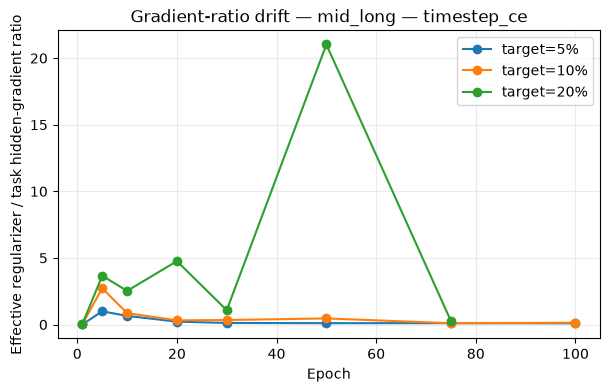

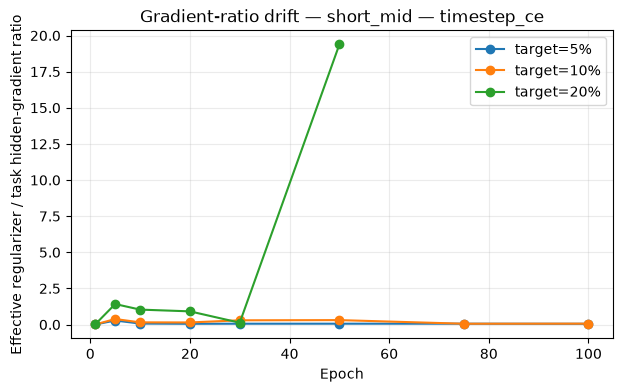

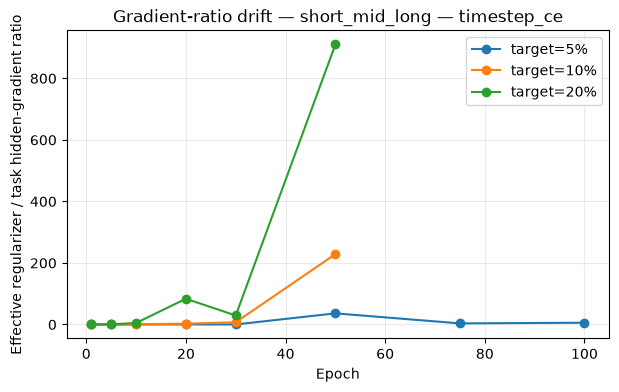

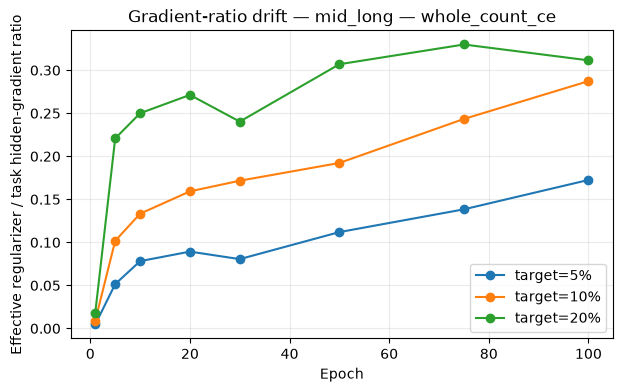

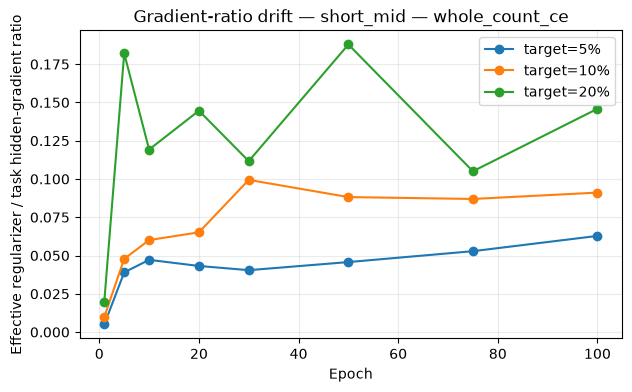

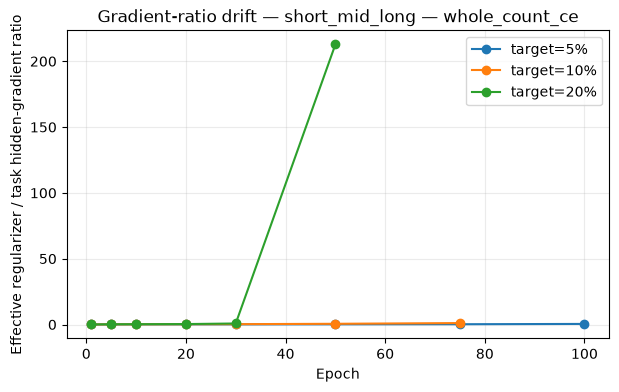

In [8]:
ratio_col = "first_batch_effective_reg_to_task_hidden_grad_ratio_mean"
for objective in sorted(gradient_summary["objective"].unique()):
    for architecture in sorted(gradient_summary["architecture"].unique()):
        fig, ax = plt.subplots(figsize=(7, 4))
        part = gradient_summary[
            (gradient_summary["objective"] == objective)
            & (gradient_summary["architecture"] == architecture)
        ]
        for target in sorted(part["target_grad_ratio"].unique()):
            sub = part[part["target_grad_ratio"] == target].sort_values("epoch")
            ax.plot(sub["epoch"], sub[ratio_col], marker="o", label=f"target={100*target:.0f}%")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Effective regularizer / task hidden-gradient ratio")
        ax.set_title(f"Gradient-ratio drift — {architecture} — {objective}")
        ax.legend()
        ax.grid(True, alpha=0.25)
        plt.show()


## Task–regularizer gradient cosine


In [9]:
cos_col = "first_batch_task_reg_hidden_grad_cosine_mean"
cosine_table = gradient_summary[
    ["target_grad_ratio", "architecture", "objective", "epoch", cos_col]
].sort_values(["architecture", "objective", "target_grad_ratio", "epoch"])
display(cosine_table.reset_index(drop=True))


,target_grad_ratio,architecture,objective,epoch,first_batch_task_reg_hidden_grad_cosine_mean
0,0.05,mid_long,timestep_ce,1,0.279678
1,0.05,mid_long,timestep_ce,5,0.026636
2,0.05,mid_long,timestep_ce,10,-0.063464
3,0.05,mid_long,timestep_ce,20,-0.089537
4,0.05,mid_long,timestep_ce,30,-0.053915
...,...,...,...,...,...
129,0.20,short_mid_long,whole_count_ce,5,-0.036551
130,0.20,short_mid_long,whole_count_ce,10,-0.092038
131,0.20,short_mid_long,whole_count_ce,20,-0.409580
132,0.20,short_mid_long,whole_count_ce,30,-0.325445


## Early stopping and checkpoint timing


In [10]:
stop_cols = [
    "target_grad_ratio", "architecture", "objective",
    "epochs_trained_mean", "epochs_trained_std",
    "best_epoch_mean", "best_epoch_std",
    "early_stopped_int_mean",
]
display(stopping_summary[stop_cols].sort_values(
    ["architecture", "objective", "target_grad_ratio"]
).reset_index(drop=True))


,target_grad_ratio,architecture,objective,epochs_trained_mean,epochs_trained_std,best_epoch_mean,best_epoch_std,early_stopped_int_mean
0,0.05,mid_long,timestep_ce,88.6,21.789906,72.6,37.971042,0.4
1,0.10,mid_long,timestep_ce,62.0,21.679483,25.0,31.709620,0.8
2,0.20,mid_long,timestep_ce,57.4,16.546903,13.6,19.819183,1.0
3,0.05,mid_long,whole_count_ce,100.0,0.000000,87.6,16.964669,0.0
4,0.10,mid_long,whole_count_ce,100.0,0.000000,89.0,5.385165,0.0
5,0.20,mid_long,whole_count_ce,96.2,8.497058,84.6,22.389730,0.2
6,0.05,short_mid,timestep_ce,100.0,0.000000,96.2,4.438468,0.0
7,0.10,short_mid,timestep_ce,80.0,27.386128,59.4,53.322603,0.4
8,0.20,short_mid,timestep_ce,52.2,4.919350,13.2,26.724521,1.0
9,0.05,short_mid,whole_count_ce,100.0,0.000000,94.6,3.209361,0.0


## Firing preservation / dead-neuron behavior


In [11]:
firing = runs.groupby(
    ["target_grad_ratio", "architecture", "objective"], dropna=False
)[[
    "test_last_hidden_events_per_neuron_second",
    "test_last_hidden_dead_neuron_fraction",
    "test_last_hidden_active_step_fraction",
]].agg(["mean", "std"]).reset_index()
firing.columns = [
    "_".join(str(x) for x in col if str(x)) if isinstance(col, tuple) else str(col)
    for col in firing.columns
]
display(firing.sort_values(
    ["architecture", "objective", "target_grad_ratio"]
).reset_index(drop=True))


,target_grad_ratio,architecture,objective,test_last_hidden_events_per_neuron_second_mean,test_last_hidden_events_per_neuron_second_std,test_last_hidden_dead_neuron_fraction_mean,test_last_hidden_dead_neuron_fraction_std,test_last_hidden_active_step_fraction_mean,test_last_hidden_active_step_fraction_std
0,0.05,mid_long,timestep_ce,1.634137,0.906385,0.096875,0.089861,0.025533,0.014162
1,0.10,mid_long,timestep_ce,1.732613,1.762236,0.220312,0.197519,0.027072,0.027535
2,0.20,mid_long,timestep_ce,2.329589,2.265018,0.207813,0.184100,0.036400,0.035391
3,0.05,mid_long,whole_count_ce,7.876607,1.495239,0.000000,0.000000,0.123072,0.023363
4,0.10,mid_long,whole_count_ce,5.606743,1.499606,0.006250,0.010186,0.087605,0.023431
5,0.20,mid_long,whole_count_ce,3.183317,1.367957,0.051562,0.059652,0.049739,0.021374
6,0.05,short_mid,timestep_ce,1.267139,1.003935,0.206250,0.148396,0.019799,0.015686
7,0.10,short_mid,timestep_ce,0.445924,0.567864,0.465625,0.257433,0.006968,0.008873
8,0.20,short_mid,timestep_ce,0.103810,0.071844,0.507812,0.095204,0.001622,0.001123
9,0.05,short_mid,whole_count_ce,7.701400,2.004756,0.009375,0.020963,0.120334,0.031324


## Validation trajectories


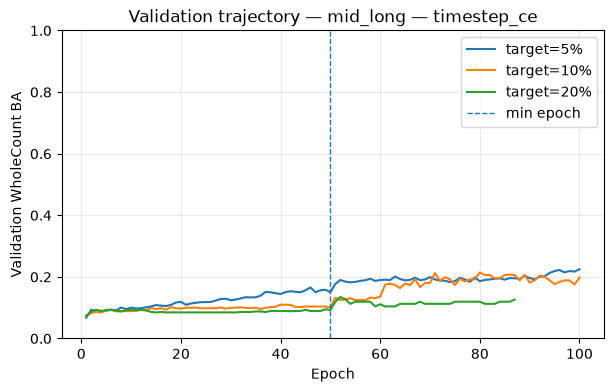

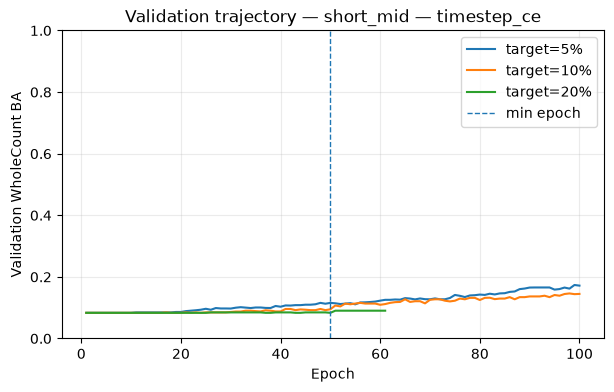

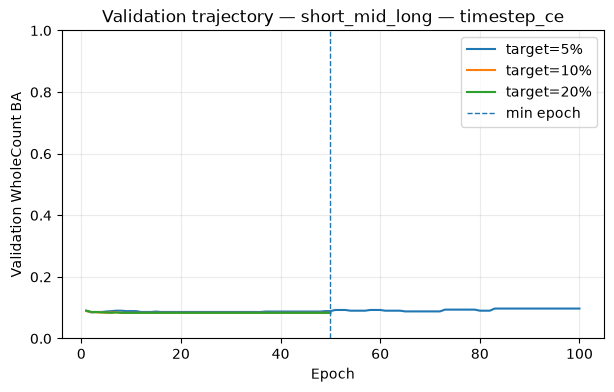

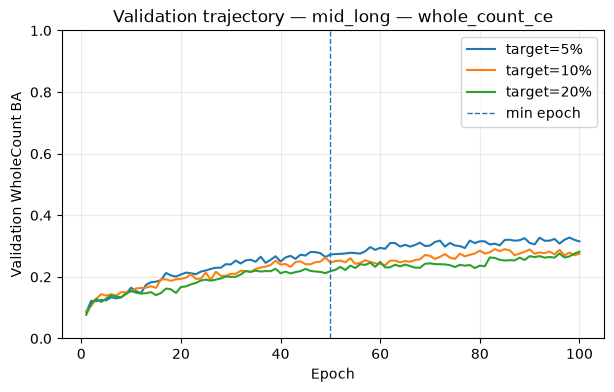

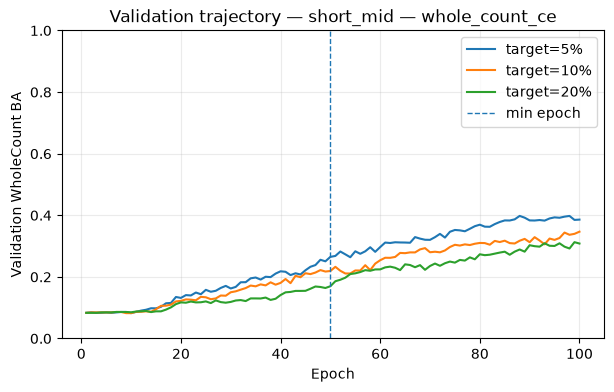

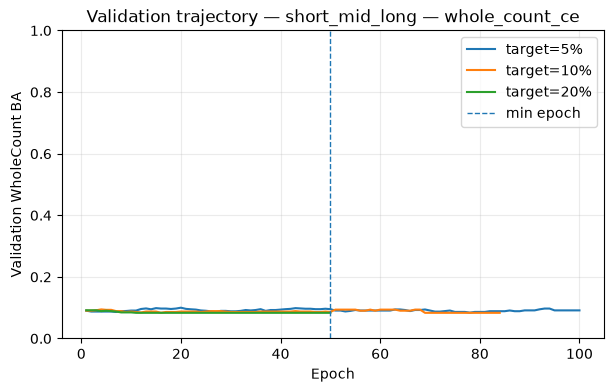

In [12]:
val_curve = history.groupby(
    ["target_grad_ratio", "architecture", "objective", "epoch"], dropna=False
)["val_wholecount_ba"].agg(["mean", "std", "count"]).reset_index()

for objective in sorted(val_curve["objective"].unique()):
    for architecture in sorted(val_curve["architecture"].unique()):
        fig, ax = plt.subplots(figsize=(7, 4))
        part = val_curve[
            (val_curve["objective"] == objective)
            & (val_curve["architecture"] == architecture)
        ]
        for target in sorted(part["target_grad_ratio"].unique()):
            sub = part[part["target_grad_ratio"] == target].sort_values("epoch")
            ax.plot(sub["epoch"], sub["mean"], label=f"target={100*target:.0f}%")
        ax.axvline(50, linestyle="--", linewidth=1, label="min epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation WholeCount BA")
        ax.set_ylim(0, 1)
        ax.set_title(f"Validation trajectory — {architecture} — {objective}")
        ax.legend()
        ax.grid(True, alpha=0.25)
        plt.show()


## Compact comparison including frozen Exp0.1


In [13]:
display(comparison.sort_values(
    ["architecture", "objective", "target_grad_ratio"]
).reset_index(drop=True))


,system,target_grad_ratio,architecture,objective,mean_test_ba,sd_test_ba,n,training_budget
0,frozen_exp0.1_no_reg,0.00,mid_long,timestep_ce,0.304034,0.044997,5,frozen Exp0.1 100 epochs
1,exp0.1.5_gradient_calibrated_all_fixes,0.05,mid_long,timestep_ce,0.205178,0.088645,5,"50-100 epochs, patience-30 after epoch 50"
2,exp0.1.5_gradient_calibrated_all_fixes,0.10,mid_long,timestep_ce,0.115766,0.058953,5,"50-100 epochs, patience-30 after epoch 50"
3,exp0.1.5_gradient_calibrated_all_fixes,0.20,mid_long,timestep_ce,0.095931,0.020354,5,"50-100 epochs, patience-30 after epoch 50"
4,frozen_exp0.1_no_reg,0.00,mid_long,whole_count_ce,0.400790,0.030637,5,frozen Exp0.1 100 epochs
5,exp0.1.5_gradient_calibrated_all_fixes,0.05,mid_long,whole_count_ce,0.373622,0.052747,5,"50-100 epochs, patience-30 after epoch 50"
6,exp0.1.5_gradient_calibrated_all_fixes,0.10,mid_long,whole_count_ce,0.377700,0.020539,5,"50-100 epochs, patience-30 after epoch 50"
7,exp0.1.5_gradient_calibrated_all_fixes,0.20,mid_long,whole_count_ce,0.318086,0.066360,5,"50-100 epochs, patience-30 after epoch 50"
8,frozen_exp0.1_no_reg,0.00,short_mid,timestep_ce,0.281464,0.025165,5,frozen Exp0.1 100 epochs
9,exp0.1.5_gradient_calibrated_all_fixes,0.05,short_mid,timestep_ce,0.212107,0.036720,5,"50-100 epochs, patience-30 after epoch 50"
